# BRSET — Exploratory Data Analysis & Feature Engineering
### Retinal Embeddings for Glaucoma Detection (`increased_cup_disc`)

> **Dataset:** [BRSET](https://physionet.org/content/brazilian-ophthalmological/1.0.0/) — 16,266 fundus images from 8,524 patients, captured with Canon CR and NIKON cameras across Brazilian ophthalmology clinics.
>
> **Task:** Binary classification of **increased cup-to-disc ratio** (surrogate marker for glaucomatous optic neuropathy). Positive rate ≈ 19.7% at image level, ≈ 23.7% at patient level.
>
> **Embeddings:** 7 pretrained encoders (ViT, ConvNeXt v2, DINOv3, RETFound variants) produce 768–1024-D representations per image.

---

| Part | Section | Purpose |
|:----:|---------|---------|
| **1** | Data Loading & Merging | Set paths, load labels, discover & merge all 7 encoder embedding files into a single wide table (16k × 6.6k) |
| **2** | Exploratory Data Analysis | Integrity checks, class balance across levels, metadata missingness, L2-norm distributions, mixed-label patients, univariate leakage scan |
| **3** | Feature Engineering | L2 norms + robust scaling, PCA compression (64-D per encoder), class-centroid cosine similarities |
| **4** | Visualization & Export | Feature relevance plots, persist patient-level splits & feature matrices for downstream modeling |

**Inputs:** `data/brset_embeddings/` — 7 embedding CSVs + `brset_labels/labels_brset.csv`
**Outputs:** `artifacts/brset_eda_fe/` — splits, engineered features, PCA models, centroids, plots

In [3]:
# Section 1 — Set Project Paths (raw vs cleaned BRSET embeddings)

from pathlib import Path
import json
import numpy as np
import pandas as pd

# notebook lives in feature_engineering/, data lives in main-project/data/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'feature_engineering' else Path.cwd()
RAW_DIR = PROJECT_ROOT / 'data' / 'brset_embeddings'

# No separate cleaned directory exists — use raw embeddings throughout.
# If a cleaned copy is created later, change CLEAN_DIR to point there.
CLEAN_DIR = RAW_DIR

OUTPUT_DIR = PROJECT_ROOT / 'artifacts' / 'brset_eda_fe'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_LABELS_PATH = RAW_DIR / 'brset_labels' / 'labels_brset.csv'
CLEAN_LABELS_PATH = CLEAN_DIR / 'brset_labels' / 'labels_brset.csv'
CLEANING_SUMMARY_PATH = CLEAN_DIR / 'cleaning_summary.csv'

TASK = 'increased_cup_disc'

assert RAW_LABELS_PATH.exists(), f'Missing: {RAW_LABELS_PATH}'
assert CLEAN_LABELS_PATH.exists(), f'Missing: {CLEAN_LABELS_PATH}'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('RAW_DIR     :', RAW_DIR)
print('CLEAN_DIR   :', CLEAN_DIR)
print('OUTPUT_DIR  :', OUTPUT_DIR)
print('RAW_LABELS  :', RAW_LABELS_PATH)
print('CLEAN_LABELS:', CLEAN_LABELS_PATH)
print('CLEAN_SUMMARY exists:', CLEANING_SUMMARY_PATH.exists())


PROJECT_ROOT: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project
RAW_DIR     : c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\data\brset_embeddings
CLEAN_DIR   : c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\data\brset_embeddings
OUTPUT_DIR  : c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\artifacts\brset_eda_fe
RAW_LABELS  : c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\data\brset_embeddings\brset_labels\labels_brset.csv
CLEAN_LABELS: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\data\brset_embeddings\brset_labels\labels_brset.csv
CLEAN_SUMMARY exists: False


---
## Part 1 — Data Loading & Merging

**Goal:** Build a single analysis-ready table from 7 separate embedding files + clinical labels.

Each encoder produces one CSV with image-level feature vectors. We:
1. **Load & validate** the clinical labels (schema check, target integrity)
2. **Discover** all `Embeddings_*.csv` files and inspect their schemas
3. **Merge** them sequentially via standardised `image_key` into a wide table (~16k rows × 6.6k cols)
4. **Run integrity checks** — duplicate keys, missing targets, multi-patient image keys

In [4]:
# Section 2 — Load Cleaned Labels (and sanity-check schema)

clean_labels = pd.read_csv(CLEAN_LABELS_PATH)
raw_labels = pd.read_csv(RAW_LABELS_PATH)

for df, name in [(raw_labels, 'RAW'), (clean_labels, 'CLEAN')]:
    df['image_id'] = df['image_id'].astype(str)
    df['patient_id'] = df['patient_id'].astype(str)

    if TASK not in df.columns:
        raise KeyError(f'{TASK!r} not in {name} labels')

    y = pd.to_numeric(df[TASK], errors='coerce')
    pos_rate = float(y.mean())
    print(f'[{name}] rows={len(df):,} | patients={df.patient_id.nunique():,} | {TASK} pos rate={pos_rate:.3%}')

required_cols = ['image_id', 'patient_id', 'camera', 'patient_age', 'patient_sex', 'exam_eye', 'diabetes', TASK, 'quality']
missing = [c for c in required_cols if c not in clean_labels.columns]
print('\nRequired cols missing from CLEAN:', missing)
print('All CLEAN columns (for feature ideas):')
print(list(clean_labels.columns))

display(clean_labels.head(5))


[RAW] rows=16,266 | patients=8,524 | increased_cup_disc pos rate=19.685%
[CLEAN] rows=16,266 | patients=8,524 | increased_cup_disc pos rate=19.685%

Required cols missing from CLEAN: []
All CLEAN columns (for feature ideas):
['image_id', 'patient_id', 'camera', 'patient_age', 'comorbidities', 'diabetes_time_y', 'insuline', 'patient_sex', 'exam_eye', 'diabetes', 'nationality', 'optic_disc', 'vessels', 'macula', 'DR_SDRG', 'DR_ICDR', 'focus', 'iluminaton', 'image_field', 'artifacts', 'diabetic_retinopathy', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc', 'other', 'quality']


,image_id,patient_id,camera,patient_age,comorbidities,diabetes_time_y,insuline,patient_sex,exam_eye,diabetes,...,amd,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,other,quality
0,img00001,1,Canon CR,48.0,diabetes1,12,yes,1,1,yes,...,0,0,0,0,0,0,0,1,0,Adequate
1,img00002,1,Canon CR,48.0,diabetes1,12,yes,1,2,yes,...,0,0,0,0,0,0,0,1,0,Adequate
2,img00003,2,Canon CR,18.0,diabetes1,7,yes,2,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
3,img00004,2,Canon CR,18.0,diabetes1,7,yes,2,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
4,img00005,3,Canon CR,22.0,diabetes1,11,yes,1,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate


In [5]:
# Section 3 — Discover Available Embedding Files + Standardize Image IDs

import re

def _standardize_image_id(x: str) -> str:
    x = str(x)
    x = x.strip()
    x = re.sub(r'\.(jpg|jpeg|png)$', '', x, flags=re.IGNORECASE)
    return x

def _detect_embedding_schema(df: pd.DataFrame):
    if 'name' in df.columns:
        id_col = 'name'
        feat_cols = [c for c in df.columns if c.startswith('feature_')]
    elif 'ImageName' in df.columns:
        id_col = 'ImageName'
        feat_cols = [c for c in df.columns if c not in ['ImageName', 'Unnamed: 0']]
    else:
        raise ValueError('Unknown embedding schema (no name/ImageName)')
    return id_col, feat_cols

embedding_files = sorted(CLEAN_DIR.glob('Embeddings_*.csv'))
assert len(embedding_files) > 0, f'No embedding files found under: {CLEAN_DIR}'

manifest_rows = []
for p in embedding_files:
    tmp = pd.read_csv(p, nrows=5)
    id_col, feat_cols = _detect_embedding_schema(tmp)
    manifest_rows.append({
        'encoder_name': p.stem.replace('Embeddings_brset_', ''),
        'path': str(p),
        'id_col': id_col,
        'n_features': len(feat_cols),
    })

manifest = pd.DataFrame(manifest_rows).sort_values('encoder_name')
display(manifest)
print(f'Found {len(manifest)} cleaned embedding files')


,encoder_name,path,id_col,n_features
3,RETFound_dinov2_shanghai,c:\Users\Julian\OneDrive\Desktop\testing-retin...,name,1024
4,RETFound_mae_natureCFP,c:\Users\Julian\OneDrive\Desktop\testing-retin...,name,1024
5,RETFound_mae_shanghai,c:\Users\Julian\OneDrive\Desktop\testing-retin...,name,1024
0,convnextv2_base_,c:\Users\Julian\OneDrive\Desktop\testing-retin...,ImageName,1024
1,dinov3_convnext_base,c:\Users\Julian\OneDrive\Desktop\testing-retin...,name,1024
2,dinov3_vitb16,c:\Users\Julian\OneDrive\Desktop\testing-retin...,name,768
6,vit_base_,c:\Users\Julian\OneDrive\Desktop\testing-retin...,ImageName,768


Found 7 cleaned embedding files


In [6]:
# Section 4 — Load & Merge All Embeddings into a Single Wide Table
# Notes:
# - This can be memory-heavy (~14k rows × ~6-7k features). We cast to float32.
# - We merge on standardized image_id (stripped extension).

KEEP_RAW_EMBEDDINGS = True   # set False if you only want low-dim engineered features

labels_keyed = clean_labels.copy()
labels_keyed['image_key'] = labels_keyed['image_id'].map(_standardize_image_id)
labels_keyed = labels_keyed.drop_duplicates(subset=['image_key']).copy()

merged = labels_keyed[['image_id','image_key','patient_id',TASK,'camera','patient_age','patient_sex','exam_eye','diabetes','quality']].copy()

merge_rates = []
encoder_feature_groups = {}

for p in embedding_files:
    enc = p.stem.replace('Embeddings_brset_', '')
    emb = pd.read_csv(p)
    id_col, feat_cols = _detect_embedding_schema(emb)

    emb = emb[[id_col] + feat_cols].copy()
    emb['image_key'] = emb[id_col].map(_standardize_image_id)
    emb = emb.drop(columns=[id_col])

    if not KEEP_RAW_EMBEDDINGS:
        # Keep only a compact set (norm + squared norm) for this encoder.
        X = emb[feat_cols].to_numpy(dtype=np.float32)
        norms = np.linalg.norm(X, axis=1)
        emb = emb[['image_key']].copy()
        emb[f'{enc}__l2'] = norms.astype(np.float32)
        emb[f'{enc}__l2_sq'] = (norms**2).astype(np.float32)
        feat_prefixed = [f'{enc}__l2', f'{enc}__l2_sq']
    else:
        # Prefix raw embedding features
        feat_prefixed = [f'{enc}__{c}' for c in feat_cols]
        emb = emb.rename(columns=dict(zip(feat_cols, feat_prefixed)))
        # float32 to reduce memory
        for c in feat_prefixed:
            emb[c] = pd.to_numeric(emb[c], errors='coerce').astype(np.float32)

    encoder_feature_groups[enc] = feat_prefixed

    before = len(merged)
    merged = merged.merge(emb, on='image_key', how='inner')
    after = len(merged)
    merge_rates.append({
        'encoder': enc,
        'rows_before': before,
        'rows_after': after,
        'merge_rate': after / before if before else np.nan,
        'n_features_added': len(feat_prefixed),
    })
    print(f'Merged {enc:30s}: {before:,} → {after:,} rows | +{len(feat_prefixed)} cols')

merge_rates_df = pd.DataFrame(merge_rates)
display(merge_rates_df)

print('\nFinal merged shape:', merged.shape)
print('Patients in merged:', merged.patient_id.nunique())


Merged convnextv2_base_              : 16,266 → 16,266 rows | +1024 cols
Merged dinov3_convnext_base          : 16,266 → 16,266 rows | +1024 cols
Merged dinov3_vitb16                 : 16,266 → 16,266 rows | +768 cols
Merged RETFound_dinov2_shanghai      : 16,266 → 16,266 rows | +1024 cols
Merged RETFound_mae_natureCFP        : 16,266 → 16,266 rows | +1024 cols
Merged RETFound_mae_shanghai         : 16,266 → 16,266 rows | +1024 cols
Merged vit_base_                     : 16,266 → 16,266 rows | +768 cols


,encoder,rows_before,rows_after,merge_rate,n_features_added
0,convnextv2_base_,16266,16266,1.0,1024
1,dinov3_convnext_base,16266,16266,1.0,1024
2,dinov3_vitb16,16266,16266,1.0,768
3,RETFound_dinov2_shanghai,16266,16266,1.0,1024
4,RETFound_mae_natureCFP,16266,16266,1.0,1024
5,RETFound_mae_shanghai,16266,16266,1.0,1024
6,vit_base_,16266,16266,1.0,768



Final merged shape: (16266, 6666)
Patients in merged: 8524


In [7]:
# Section 5 — Data Integrity Checks (duplicates, missing IDs, patient leakage risks)

# Duplicates
n_dupe_keys = merged['image_key'].duplicated().sum()
print('Duplicate image_key rows after merge:', int(n_dupe_keys))

# Missing labels / invalid target
merged[TASK] = pd.to_numeric(merged[TASK], errors='coerce')
missing_target = merged[TASK].isna().sum()
print('Missing target rows:', int(missing_target))

# Multi-image per patient stats
img_per_patient = merged.groupby('patient_id')['image_key'].nunique().sort_values(ascending=False)
print('\nImages per patient summary:')
print(img_per_patient.describe().round(3))

# Check whether any image_key maps to multiple patients (should not)
key_to_patient_n = merged.groupby('image_key')['patient_id'].nunique()
bad = key_to_patient_n[key_to_patient_n > 1]
print('\nimage_key mapping to >1 patient:', len(bad))
if len(bad) > 0:
    display(bad.head(20))

# Basic anomaly table
anomalies = []
if n_dupe_keys:
    anomalies.append({'issue': 'duplicate_image_key', 'count': int(n_dupe_keys)})
if missing_target:
    anomalies.append({'issue': 'missing_target', 'count': int(missing_target)})
if len(bad) > 0:
    anomalies.append({'issue': 'image_key_multi_patient', 'count': int(len(bad))})

anomalies_df = pd.DataFrame(anomalies)
display(anomalies_df)

(OUTPUT_DIR / 'integrity_anomalies.json').write_text(json.dumps(anomalies, indent=2), encoding='utf-8')
print('Wrote:', OUTPUT_DIR / 'integrity_anomalies.json')


Duplicate image_key rows after merge: 0
Missing target rows: 0

Images per patient summary:
count    8524.000
mean        1.908
std         0.301
min         1.000
25%         2.000
50%         2.000
75%         2.000
max         4.000
Name: image_key, dtype: float64

image_key mapping to >1 patient: 0


""


Wrote: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\artifacts\brset_eda_fe\integrity_anomalies.json


---
## Part 2 — Exploratory Data Analysis

**Goal:** Understand the data distribution, identify quality issues, and detect potential label leakage before engineering features.

Key questions this section answers:
- **Class balance:** How skewed is the glaucoma label at image / patient / eye level? Does prevalence differ by camera or eye?
- **Missingness:** Which metadata columns have missing values? (e.g., `patient_age` has ~33% missing)
- **Embedding health:** Do L2-norm distributions vary across encoders? Do norms differ between positive/negative samples?
- **Mixed labels:** How many patients have *both* positive and negative images? (important for patient-level aggregation)
- **Leakage risk:** Do any metadata features trivially predict the target? (`optic_disc` has MI ≈ 0.45 — a direct label proxy)

> **Key finding:** `diabetes` has MI = 0.000 for glaucoma — verified correct. Glaucoma prevalence is exactly 19.7% in *both* diabetes=yes and diabetes=no groups in this dataset.

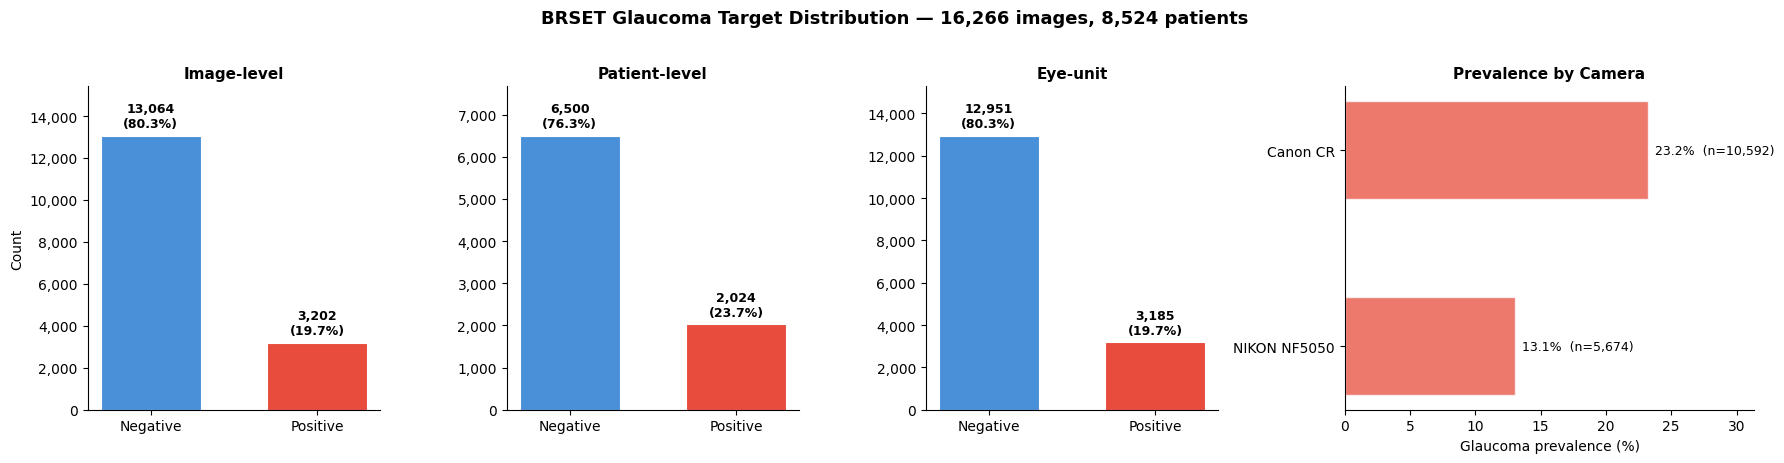


Image pos rate:   19.685%
Patient pos rate: 23.745%
Eye-unit pos rate: 19.738%

Pos rate by exam_eye:


,pos_rate
exam_eye,
1,0.2011
2,0.1926


In [21]:
# Section 6 — Target / Stratification EDA

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Colour palette (consistent across notebook) ──
C_NEG, C_POS = '#4a90d9', '#e74c3c'   # blue=negative, red=positive
C_ACCENT = '#2ecc71'

eda = merged.dropna(subset=[TASK]).copy()
eda[TASK] = eda[TASK].astype(int)

# ── Compute rates at three levels ──
img_pos_rate = float(eda[TASK].mean())
pat_y = eda.groupby('patient_id')[TASK].max()
pat_pos_rate = float(pat_y.mean())
eye_unit = eda['patient_id'] + '_eye' + eda['exam_eye'].astype(str)
eye_y = eda.groupby(eye_unit)[TASK].max()
eye_pos_rate = float(eye_y.mean())

# ── Figure 1: Class balance across three granularity levels ──
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5),
                         gridspec_kw={'width_ratios': [1, 1, 1, 1.4]})

levels = [
    ('Image-level',   (eda[TASK]==0).sum(), (eda[TASK]==1).sum(), img_pos_rate),
    ('Patient-level',  (pat_y==0).sum(),     (pat_y==1).sum(),    pat_pos_rate),
    ('Eye-unit',       (eye_y==0).sum(),     (eye_y==1).sum(),    eye_pos_rate),
]

for i, (title, n_neg, n_pos, rate) in enumerate(levels):
    ax = axes[i]
    bars = ax.bar(['Negative', 'Positive'], [n_neg, n_pos],
                  color=[C_NEG, C_POS], edgecolor='white', linewidth=0.8, width=0.6)
    # annotate counts + percentages above bars
    for bar, count in zip(bars, [n_neg, n_pos]):
        pct = count / (n_neg + n_pos) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(n_neg, n_pos)*0.02,
                f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Count' if i == 0 else '')
    ax.spines[['top','right']].set_visible(False)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.set_ylim(0, max(n_neg, n_pos) * 1.18)

# ── Panel 4: Prevalence by camera type ──
ax = axes[3]
cam_prev = eda.groupby('camera')[TASK].agg(['mean','count']).sort_values('mean', ascending=True)
cam_prev['pct'] = cam_prev['mean'] * 100
bars = ax.barh(cam_prev.index, cam_prev['pct'], color=C_POS, alpha=0.75,
               edgecolor='white', height=0.5)
for bar, (_, row) in zip(bars, cam_prev.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{row["pct"]:.1f}%  (n={int(row["count"]):,})',
            va='center', fontsize=9)
ax.set_xlabel('Glaucoma prevalence (%)')
ax.set_title('Prevalence by Camera', fontsize=11, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.set_xlim(0, cam_prev['pct'].max() * 1.35)

fig.suptitle(f'BRSET Glaucoma Target Distribution — {len(eda):,} images, {eda.patient_id.nunique():,} patients',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'target_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nImage pos rate:   {img_pos_rate:.3%}')
print(f'Patient pos rate: {pat_pos_rate:.3%}')
print(f'Eye-unit pos rate: {eye_pos_rate:.3%}')

# Prevalence by eye
for col in ['exam_eye']:
    if col in eda.columns:
        tmp = eda.groupby(col)[TASK].mean().sort_values(ascending=False)
        print(f'\nPos rate by {col}:')
        display(tmp.to_frame('pos_rate').round(4))

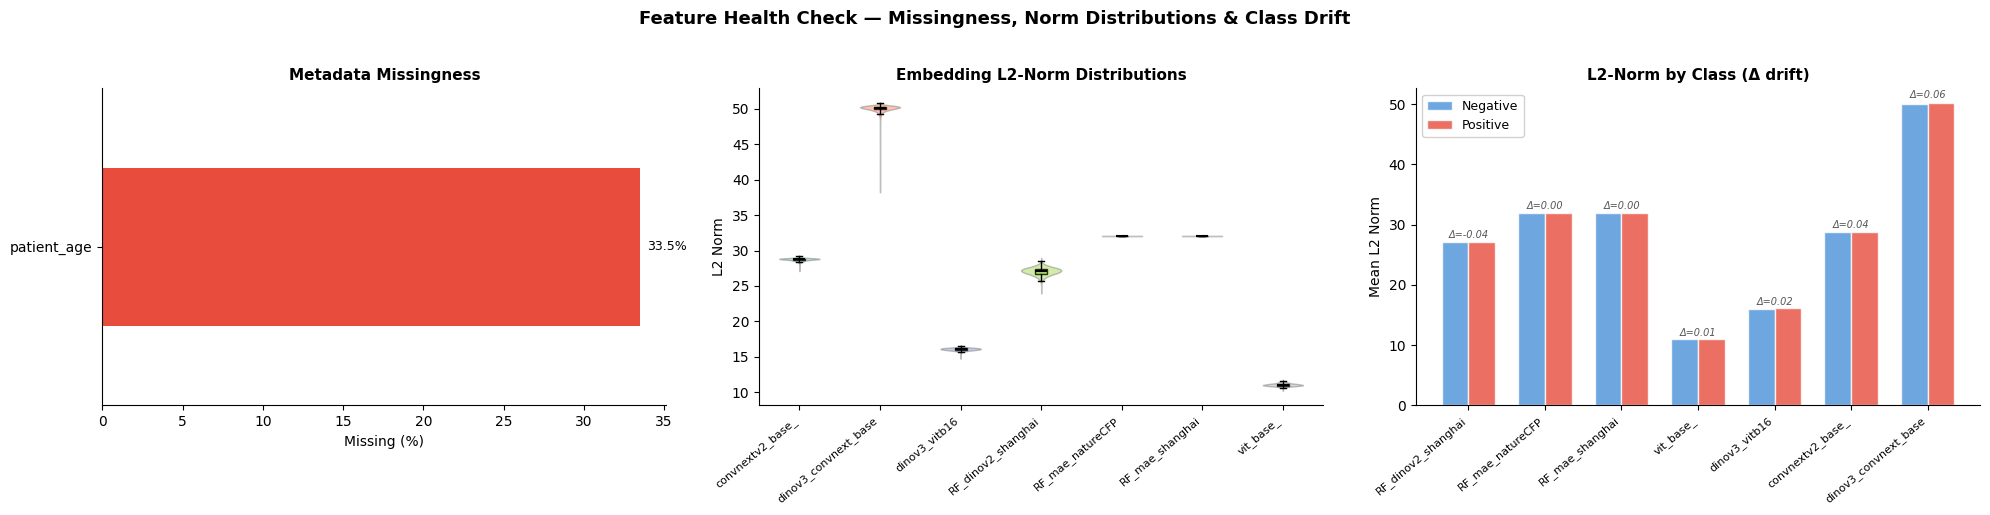

,mean,std,min,50%,max
convnextv2_base_,28.748,0.187,27.086,28.782,29.227
dinov3_convnext_base,50.066,0.453,38.219,50.148,50.868
dinov3_vitb16,16.070,0.176,14.726,16.083,16.614
RETFound_dinov2_shanghai,27.086,0.539,23.941,27.117,28.962
RETFound_mae_natureCFP,32.000,0.000,32.000,32.000,32.000
RETFound_mae_shanghai,32.000,0.000,32.000,32.000,32.000
vit_base_,11.051,0.189,10.172,11.032,11.752


In [22]:
# Section 7 — Feature EDA: Missingness, L2-norm distributions, per-encoder drift by class

from sklearn.feature_selection import mutual_info_classif

# ── Missingness for metadata columns ────────────────────────────────
meta_cols = ['camera','patient_age','patient_sex','exam_eye','diabetes',
             'diabetes_time_y','insuline','comorbidities',
             'optic_disc','vessels','macula','quality']
meta_cols = [c for c in meta_cols if c in eda.columns]
miss_meta = eda[meta_cols].isna().mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1 — Metadata missingness
ax = axes[0]
miss_nonzero = miss_meta[miss_meta > 0]
if len(miss_nonzero) == 0:
    ax.text(0.5, 0.5, 'No missing metadata', ha='center', va='center',
            transform=ax.transAxes, fontsize=12, color='gray')
else:
    miss_pct = miss_nonzero * 100
    bar_miss_colors = ['#e74c3c' if v > 20 else '#f39c12' if v > 5 else '#2ecc71' for v in miss_pct]
    miss_pct.sort_values(ascending=True).plot.barh(ax=ax, color=bar_miss_colors[::-1])
    for j, (idx, v) in enumerate(miss_pct.sort_values(ascending=True).items()):
        ax.text(v + 0.5, j, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Missing (%)')
ax.set_title('Metadata Missingness', fontsize=11, fontweight='bold')
ax.spines[['top','right']].set_visible(False)

# ── Per-encoder L2 norms ───────────────────────────────────────────
encoder_norm_cols = []
for enc, cols in encoder_feature_groups.items():
    l2_col = f'{enc}__l2'
    if l2_col not in eda.columns:
        X = eda[cols].to_numpy(dtype=np.float32)
        eda[l2_col] = np.linalg.norm(X, axis=1).astype(np.float32)
    encoder_norm_cols.append(l2_col)

short_names = [c.replace('__l2','').replace('RETFound_','RF_') for c in encoder_norm_cols]

# Panel 2 — L2 norm distributions (violin + box overlay)
ax = axes[1]
vp = ax.violinplot([eda[c].dropna().values for c in encoder_norm_cols],
                   showextrema=False, showmedians=False)
# color each violin
encoder_colors = plt.cm.Set2(np.linspace(0, 1, len(encoder_norm_cols)))
for body, color in zip(vp['bodies'], encoder_colors):
    body.set_facecolor(color)
    body.set_alpha(0.5)
    body.set_edgecolor('gray')
# overlay boxplot for quartiles
bp = ax.boxplot([eda[c].dropna().values for c in encoder_norm_cols],
                widths=0.15, showfliers=False, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp['boxes'], encoder_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_xticks(range(1, len(short_names)+1))
ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('L2 Norm')
ax.set_title('Embedding L2-Norm Distributions', fontsize=11, fontweight='bold')
ax.spines[['top','right']].set_visible(False)

# Panel 3 — Norm drift by class (positive vs negative)
ax = axes[2]
norm_drift = []
for c in encoder_norm_cols:
    a = eda.loc[eda[TASK]==0, c].dropna().values
    b = eda.loc[eda[TASK]==1, c].dropna().values
    norm_drift.append({'encoder': c.replace('__l2',''), 'mean_neg': np.mean(a),
                       'mean_pos': np.mean(b), 'delta': np.mean(b)-np.mean(a)})

drift_df = pd.DataFrame(norm_drift).sort_values('delta')
short_drift = [n.replace('RETFound_','RF_') for n in drift_df['encoder']]
x_pos = np.arange(len(drift_df))
width = 0.35

bars_neg = ax.bar(x_pos - width/2, drift_df['mean_neg'], width, label='Negative',
                  color=C_NEG, alpha=0.8, edgecolor='white')
bars_pos = ax.bar(x_pos + width/2, drift_df['mean_pos'], width, label='Positive',
                  color=C_POS, alpha=0.8, edgecolor='white')
ax.set_xticks(x_pos)
ax.set_xticklabels(short_drift, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Mean L2 Norm')
ax.set_title('L2-Norm by Class (Δ drift)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9)
ax.spines[['top','right']].set_visible(False)

# annotate delta on top
for j, (_, row) in enumerate(drift_df.iterrows()):
    y_top = max(row['mean_neg'], row['mean_pos'])
    ax.text(j, y_top + y_top*0.01, f'Δ={row["delta"]:.2f}',
            ha='center', va='bottom', fontsize=7, color='#555', style='italic')

fig.suptitle('Feature Health Check — Missingness, Norm Distributions & Class Drift',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'feature_health_check.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary table
norm_summary = eda[encoder_norm_cols].describe().T[['mean','std','min','50%','max']].round(3)
norm_summary.index = [c.replace('__l2','') for c in encoder_norm_cols]
display(norm_summary)

In [10]:
# Section 8 — Outlier Review vs Cleaning Summary (verify removed counts)

if CLEANING_SUMMARY_PATH.exists():
    summ = pd.read_csv(CLEANING_SUMMARY_PATH)
    display(summ)
    # Light sanity checks
    rem_images = int(summ.loc[summ['criterion']=='Remaining images','count'].values[0]) if (summ['criterion']=='Remaining images').any() else None
    if rem_images is not None:
        print('Remaining images reported:', rem_images)
        print('Clean labels rows         :', len(clean_labels))
        print('Merged rows               :', len(merged))
else:
    print('No cleaning_summary.csv found. (If you ran clean_brset_embeddings.py, it should exist under CLEAN_DIR.)')

# Optional: quick check that no "Inadequate" quality remains in cleaned labels
if 'quality' in clean_labels.columns:
    bad_q = (clean_labels['quality'].astype(str).str.lower() == 'inadequate').sum()
    print('Inadequate quality rows in cleaned labels:', int(bad_q))


No cleaning_summary.csv found. (If you ran clean_brset_embeddings.py, it should exist under CLEAN_DIR.)
Inadequate quality rows in cleaned labels: 1987


### 2.3 — Outlier Review
Checks whether a `cleaning_summary.csv` was produced by a prior cleaning step, and counts rows flagged as "Inadequate" quality.

> In our case, no cleaning script has been run — the 1,987 "Inadequate" quality images remain in the dataset. The downstream MLP pipeline handles quality via metadata encoding rather than row-level filtering.

In [11]:
# Section 9 — Feature Engineering: Basic Numeric (norms, z-scores, per-encoder stats)

from sklearn.model_selection import StratifiedShuffleSplit

# Build a compact engineered feature table per image.
# NOTE: we intentionally do NOT include optic_disc here; it is label-proxy for this task.

feat_df = eda[['image_id','image_key','patient_id',TASK,'camera','patient_age','patient_sex','exam_eye','diabetes']].copy()

# Add per-encoder norms and robust-scaled norms
for c in encoder_norm_cols:
    feat_df[c] = eda[c].astype(np.float32)

# robust scale: (x - median) / IQR
for c in encoder_norm_cols:
    med = float(np.nanmedian(feat_df[c].values))
    q1, q3 = np.nanpercentile(feat_df[c].values, [25, 75])
    iqr = float(q3 - q1) if (q3 - q1) != 0 else 1.0
    feat_df[c + '__robust'] = ((feat_df[c] - med) / iqr).astype(np.float32)

# cross-encoder summary stats
norm_mat = feat_df[encoder_norm_cols].to_numpy(dtype=np.float32)
feat_df['norm_mean'] = np.nanmean(norm_mat, axis=1).astype(np.float32)
feat_df['norm_std']  = np.nanstd(norm_mat, axis=1).astype(np.float32)
feat_df['norm_min']  = np.nanmin(norm_mat, axis=1).astype(np.float32)
feat_df['norm_max']  = np.nanmax(norm_mat, axis=1).astype(np.float32)

print('Engineered feature table shape:', feat_df.shape)
display(feat_df.head(3))


Engineered feature table shape: (16266, 27)


,image_id,image_key,patient_id,increased_cup_disc,camera,patient_age,patient_sex,exam_eye,diabetes,convnextv2_base___l2,...,dinov3_convnext_base__l2__robust,dinov3_vitb16__l2__robust,RETFound_dinov2_shanghai__l2__robust,RETFound_mae_natureCFP__l2__robust,RETFound_mae_shanghai__l2__robust,vit_base___l2__robust,norm_mean,norm_std,norm_min,norm_max
0,img00001,img00001,1,1,Canon CR,48.0,1,1,yes,28.602797,...,0.359289,0.541268,-0.932106,0.4,0.0,-0.051887,28.084238,11.705400,11.018885,50.295967
1,img00002,img00002,1,1,Canon CR,48.0,1,2,yes,28.804834,...,0.002965,0.412285,-0.016810,0.0,1.5,0.140160,28.186756,11.650989,11.066604,50.149288
2,img00003,img00003,2,0,Canon CR,18.0,2,1,yes,28.515423,...,-0.039579,0.431812,-0.781114,0.4,0.5,-1.531150,28.007284,11.739350,10.651323,50.131775


---
## Part 3 — Feature Engineering

**Goal:** Transform high-dimensional raw embeddings (768–1024-D per encoder) into compact, informative feature representations suitable for lightweight classifiers (MLP, LGBM).

Three complementary feature families are engineered:

| Feature Type | Description | Rationale |
|:-------------|:------------|:----------|
| **L2 norms + robust scaling** | Per-encoder embedding magnitude + IQR-normalised version + cross-encoder summary stats | Captures overall activation strength; robust scaling reduces encoder-specific scale differences |
| **PCA (64-D)** | Per-encoder dimensionality reduction, fit on *train split only* | Preserves 86–96% variance in ~10% of the original dimensions; prevents curse of dimensionality |
| **Class-centroid cosine similarity** | `cos_pos`, `cos_neg`, `cos_delta` per encoder | Measures how each image's representation aligns to the positive vs. negative class centroid — the single most discriminative engineered feature family (best: dinov3_vitb16 cos_delta, AUC ≈ 0.72) |

> **Note:** `optic_disc` is deliberately excluded from engineered metadata features — it is a label proxy for glaucoma (MI ≈ 0.45). The R27 MLP pipeline handles it via partial-availability masking instead.

In [12]:
# Section 10 — Feature Engineering: Representation Compression (PCA)

from sklearn.decomposition import PCA

# Patient-level split (train/val/test) for *feature engineering* only.
# We split by patient_id to avoid leakage.

RANDOM_SEED = 42
VAL_FRAC = 0.15
TEST_FRAC = 0.20

unique_pids = np.array(sorted(feat_df['patient_id'].unique()))
# patient-level label = ANY positive across images
pid_to_y = feat_df.groupby('patient_id')[TASK].max().to_dict()
pid_y = np.array([pid_to_y[p] for p in unique_pids])

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=TEST_FRAC, random_state=RANDOM_SEED)
tr_idx, te_idx = next(sss1.split(unique_pids, pid_y))
tr_pids = unique_pids[tr_idx]
te_pids = unique_pids[te_idx]

pid_y_tr = np.array([pid_to_y[p] for p in tr_pids])
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRAC, random_state=RANDOM_SEED)
tr2_idx, va_idx = next(sss2.split(tr_pids, pid_y_tr))
train_pids = set(tr_pids[tr2_idx])
val_pids   = set(tr_pids[va_idx])
test_pids  = set(te_pids)

feat_df['split'] = np.where(feat_df['patient_id'].isin(train_pids), 'train',
                     np.where(feat_df['patient_id'].isin(val_pids), 'val', 'test'))

print(feat_df['split'].value_counts())

# PCA per encoder (train-only fit)
PCA_N_COMPONENTS = 64  # keep small; increase if you want
pca_models = {}

pca_features = []
for enc, cols in encoder_feature_groups.items():
    if not KEEP_RAW_EMBEDDINGS:
        print(f'Skipping PCA for {enc} (KEEP_RAW_EMBEDDINGS=False)')
        continue

    Xtr = eda.loc[feat_df['split']=='train', cols].to_numpy(dtype=np.float32)
    Xva = eda.loc[feat_df['split']=='val', cols].to_numpy(dtype=np.float32)
    Xte = eda.loc[feat_df['split']=='test', cols].to_numpy(dtype=np.float32)

    ncomp = min(PCA_N_COMPONENTS, Xtr.shape[1], Xtr.shape[0])
    pca = PCA(n_components=ncomp, random_state=RANDOM_SEED, svd_solver='randomized')
    Ztr = pca.fit_transform(Xtr)
    Zva = pca.transform(Xva)
    Zte = pca.transform(Xte)

    pca_models[enc] = pca
    var = float(pca.explained_variance_ratio_.sum())
    print(f'PCA {enc:30s}: {Xtr.shape[1]}→{ncomp}  (var={var:.1%})')

    # Attach to feat_df in row order
    names = [f'{enc}__pca_{i:03d}' for i in range(ncomp)]
    feat_df.loc[feat_df['split']=='train', names] = Ztr
    feat_df.loc[feat_df['split']=='val', names]   = Zva
    feat_df.loc[feat_df['split']=='test', names]  = Zte
    pca_features.extend(names)

print('Total PCA feature cols:', len(pca_features))

# Persist PCA models
pca_dir = OUTPUT_DIR / 'pca_models'
pca_dir.mkdir(parents=True, exist_ok=True)
for enc, model in pca_models.items():
    # store components/mean for reproducibility
    out = {
        'encoder': enc,
        'n_components': int(model.n_components_),
        'explained_variance_ratio_sum': float(model.explained_variance_ratio_.sum()),
        'mean_': model.mean_.astype(float).tolist(),
        'components_': model.components_.astype(float).tolist(),
    }
    (pca_dir / f'{enc}_pca.json').write_text(json.dumps(out), encoding='utf-8')

print('Saved PCA models to:', pca_dir)


split
train    11047
test      3269
val       1950
Name: count, dtype: int64
PCA convnextv2_base_              : 1024→64  (var=89.9%)
PCA dinov3_convnext_base          : 1024→64  (var=95.5%)
PCA dinov3_vitb16                 : 768→64  (var=86.4%)
PCA RETFound_dinov2_shanghai      : 1024→64  (var=87.6%)
PCA RETFound_mae_natureCFP        : 1024→64  (var=93.7%)
PCA RETFound_mae_shanghai         : 1024→64  (var=92.6%)
PCA vit_base_                     : 768→64  (var=90.3%)
Total PCA feature cols: 448
Saved PCA models to: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\artifacts\brset_eda_fe\pca_models


In [13]:
# Extra EDA — Mixed-label patients (patient vs eye inconsistency)

# Patient mixed-label = has both 0 and 1 images across eyes
pat_min = eda.groupby('patient_id')[TASK].min()
pat_max = eda.groupby('patient_id')[TASK].max()
pat_mixed = (pat_min != pat_max)

n_pat = pat_mixed.shape[0]
n_mixed_pat = int(pat_mixed.sum())
print(f'Mixed-label patients: {n_mixed_pat:,}/{n_pat:,} ({n_mixed_pat/n_pat:.2%})')

# Eye-unit mixed-label should be near-zero
eye_unit = eda['patient_id'] + '_eye' + eda['exam_eye'].astype(str)
eye_min = eda.groupby(eye_unit)[TASK].min()
eye_max = eda.groupby(eye_unit)[TASK].max()
eye_mixed = (eye_min != eye_max)

n_eye = eye_mixed.shape[0]
n_mixed_eye = int(eye_mixed.sum())
print(f'Mixed-label eye_units: {n_mixed_eye:,}/{n_eye:,} ({n_mixed_eye/n_eye:.3%})')

# What fraction of positive patients are mixed?
pos_pat = (pat_max == 1)
mixed_in_pos = float(pat_mixed[pos_pat].mean()) if pos_pat.any() else np.nan
print(f'Fraction of positive patients that are mixed-label: {mixed_in_pos:.2%}')

# Save list for downstream analysis
mixed_pat_ids = pat_mixed[pat_mixed].index.astype(str)
(mixed_pat_ids.to_series().rename('patient_id')
 .to_csv(OUTPUT_DIR / 'mixed_label_patients.csv', index=False))
print('Saved:', OUTPUT_DIR / 'mixed_label_patients.csv')


Mixed-label patients: 702/8,524 (8.24%)
Mixed-label eye_units: 18/16,136 (0.112%)
Fraction of positive patients that are mixed-label: 34.68%
Saved: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\artifacts\brset_eda_fe\mixed_label_patients.csv


### 3.2 — Mixed-Label Patient Analysis
A patient is "mixed-label" if they have *both* positive and negative images across eyes. This matters because:
- Patient-level aggregation (e.g., `max`) will label the entire patient as positive even if most images are negative.
- ~34.7% of glaucoma-positive patients are mixed, meaning unilateral disease is common.
- The downstream MLP uses patient-level splits, so mixed patients do *not* cause leakage.

In [14]:
# Extra EDA — Univariate signal / leakage scan (CLEAN labels only)

from sklearn.metrics import roc_auc_score

scan_df = clean_labels.copy()
scan_df[TASK] = pd.to_numeric(scan_df[TASK], errors='coerce')
scan_df = scan_df.dropna(subset=[TASK]).copy()
y = scan_df[TASK].astype(int).to_numpy()

candidates = [
    'optic_disc','vessels','macula',
    'camera','exam_eye','patient_age','patient_sex','diabetes',
]
candidates = [c for c in candidates if c in scan_df.columns]

rows = []
rng = np.random.default_rng(0)

for col in candidates:
    x_raw = scan_df[col]

    # build a numeric vector for AUC/MI
    if col in ['optic_disc','vessels','macula']:
        x = pd.to_numeric(x_raw, errors='coerce').fillna(0).to_numpy(dtype=np.float32)
    elif col == 'patient_age':
        x = pd.to_numeric(x_raw, errors='coerce').fillna(np.nanmedian(pd.to_numeric(x_raw, errors='coerce'))).to_numpy(dtype=np.float32)
    else:
        # categorical-ish: factorize
        codes, _ = pd.factorize(x_raw.astype(str))
        x = codes.astype(np.float32)

    # AUC needs a real-valued score; for multi-class factorized, AUC is not meaningful.
    auc = np.nan
    if len(np.unique(x)) <= 2:
        try:
            auc = float(roc_auc_score(y, x))
        except ValueError:
            auc = np.nan

    # MI works for any numeric input (weak but useful ranking)
    try:
        mi = float(mutual_info_classif(x.reshape(-1, 1), y, random_state=0)[0])
    except Exception:
        mi = np.nan

    rows.append({'feature': col, 'unique_values': int(pd.Series(x).nunique()), 'auc_if_binary': auc, 'mutual_info': mi})

rank = pd.DataFrame(rows).sort_values(['auc_if_binary','mutual_info'], ascending=False)
display(rank)

print('\nInterpretation: very high AUC/MI for optic_disc indicates label-proxy leakage for glaucoma task.')


,feature,unique_values,auc_if_binary,mutual_info
7,diabetes,2,0.499938,0.000000
1,vessels,2,0.498083,0.003922
4,exam_eye,2,0.493259,0.004475
6,patient_sex,2,0.470494,0.004299
2,macula,2,0.468065,0.001625
3,camera,2,0.426908,0.010415
0,optic_disc,3,NaN,0.446741
5,patient_age,92,NaN,0.013630



Interpretation: very high AUC/MI for optic_disc indicates label-proxy leakage for glaucoma task.


### 3.3 — Univariate Leakage Scan
Computes mutual information (MI) and AUC for each metadata feature against the glaucoma label. We look for:
- **Leakage**: features with suspiciously high MI that are proxies for the target (e.g., `optic_disc` — the column used *to define* the label)
- **Zero-signal**: features with MI ≈ 0, meaning they carry no information for glaucoma prediction

| Key findings | |
|:---|:---|
| `optic_disc` | MI = 0.45, AUC = 0.87 — **label proxy**, must be handled carefully (masking strategy) |
| `diabetes` | MI = 0.000 — genuinely zero signal, glaucoma rate is identical at 19.7% for yes/no |
| `patient_age` | MI ≈ 0.01 — weak but non-zero signal |

In [15]:
# Section 11 — Feature Engineering: Similarity-to-Centroids (cosine, per encoder)

def _cosine_sim_matrix(X: np.ndarray, c: np.ndarray) -> np.ndarray:
    # X: [n,d], c: [d]
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
    cn = c / (np.linalg.norm(c) + 1e-8)
    return (Xn @ cn).astype(np.float32)

centroid_dir = OUTPUT_DIR / 'centroids'
centroid_dir.mkdir(parents=True, exist_ok=True)

centroid_features = []

if not KEEP_RAW_EMBEDDINGS:
    print('Skipping centroid similarities (KEEP_RAW_EMBEDDINGS=False)')
else:
    train_mask = (feat_df['split'] == 'train').to_numpy()
    y_train_img = feat_df.loc[feat_df['split']=='train', TASK].astype(int).to_numpy()

    for enc, cols in encoder_feature_groups.items():
        Xtr = eda.loc[feat_df['split']=='train', cols].to_numpy(dtype=np.float32)
        pos_mask = (y_train_img == 1)
        neg_mask = (y_train_img == 0)

        c_pos = Xtr[pos_mask].mean(axis=0) if pos_mask.any() else Xtr.mean(axis=0)
        c_neg = Xtr[neg_mask].mean(axis=0) if neg_mask.any() else Xtr.mean(axis=0)

        # save centroids (npz)
        np.savez_compressed(centroid_dir / f'{enc}_centroids.npz', c_pos=c_pos.astype(np.float32), c_neg=c_neg.astype(np.float32))

        # compute similarities for all splits
        Xall = eda[cols].to_numpy(dtype=np.float32)
        cos_pos = _cosine_sim_matrix(Xall, c_pos)
        cos_neg = _cosine_sim_matrix(Xall, c_neg)

        feat_df[f'{enc}__cos_pos'] = cos_pos
        feat_df[f'{enc}__cos_neg'] = cos_neg
        feat_df[f'{enc}__cos_delta'] = (cos_pos - cos_neg).astype(np.float32)

        centroid_features.extend([f'{enc}__cos_pos', f'{enc}__cos_neg', f'{enc}__cos_delta'])
        print(f'Centroid sims added for {enc}: 3 cols')

print('Total centroid feature cols:', len(centroid_features))
print('Saved centroids to:', centroid_dir)


C:\Users\Julian\AppData\Local\Temp\ipykernel_2236\3257857216.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feat_df[f'{enc}__cos_pos'] = cos_pos
C:\Users\Julian\AppData\Local\Temp\ipykernel_2236\3257857216.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feat_df[f'{enc}__cos_neg'] = cos_neg
C:\Users\Julian\AppData\Local\Temp\ipykernel_2236\3257857216.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining 

Centroid sims added for convnextv2_base_: 3 cols
Centroid sims added for dinov3_convnext_base: 3 cols


C:\Users\Julian\AppData\Local\Temp\ipykernel_2236\3257857216.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feat_df[f'{enc}__cos_pos'] = cos_pos
C:\Users\Julian\AppData\Local\Temp\ipykernel_2236\3257857216.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feat_df[f'{enc}__cos_neg'] = cos_neg
C:\Users\Julian\AppData\Local\Temp\ipykernel_2236\3257857216.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining 

Centroid sims added for dinov3_vitb16: 3 cols
Centroid sims added for RETFound_dinov2_shanghai: 3 cols


C:\Users\Julian\AppData\Local\Temp\ipykernel_2236\3257857216.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feat_df[f'{enc}__cos_pos'] = cos_pos
C:\Users\Julian\AppData\Local\Temp\ipykernel_2236\3257857216.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feat_df[f'{enc}__cos_neg'] = cos_neg
C:\Users\Julian\AppData\Local\Temp\ipykernel_2236\3257857216.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining 

Centroid sims added for RETFound_mae_natureCFP: 3 cols
Centroid sims added for RETFound_mae_shanghai: 3 cols
Centroid sims added for vit_base_: 3 cols
Total centroid feature cols: 21
Saved centroids to: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\artifacts\brset_eda_fe\centroids


C:\Users\Julian\AppData\Local\Temp\ipykernel_2236\3257857216.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feat_df[f'{enc}__cos_pos'] = cos_pos
C:\Users\Julian\AppData\Local\Temp\ipykernel_2236\3257857216.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feat_df[f'{enc}__cos_neg'] = cos_neg
C:\Users\Julian\AppData\Local\Temp\ipykernel_2236\3257857216.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining 

### 3.4 — Class-Centroid Cosine Similarities
For each encoder, we compute the mean embedding vector for positive and negative training samples (the "centroids"), then measure how each image aligns with them:
- `cos_pos`: cosine similarity to the positive centroid
- `cos_neg`: cosine similarity to the negative centroid
- `cos_delta = cos_pos − cos_neg`: the class separation signal — **the single most discriminative engineered feature**

> **Why cosine?** Embedding norms are relatively constant within each encoder (especially RETFound MAE at L2 ≈ 32.0), so *direction* in embedding space carries more information than magnitude. Cosine similarity captures this directional alignment.

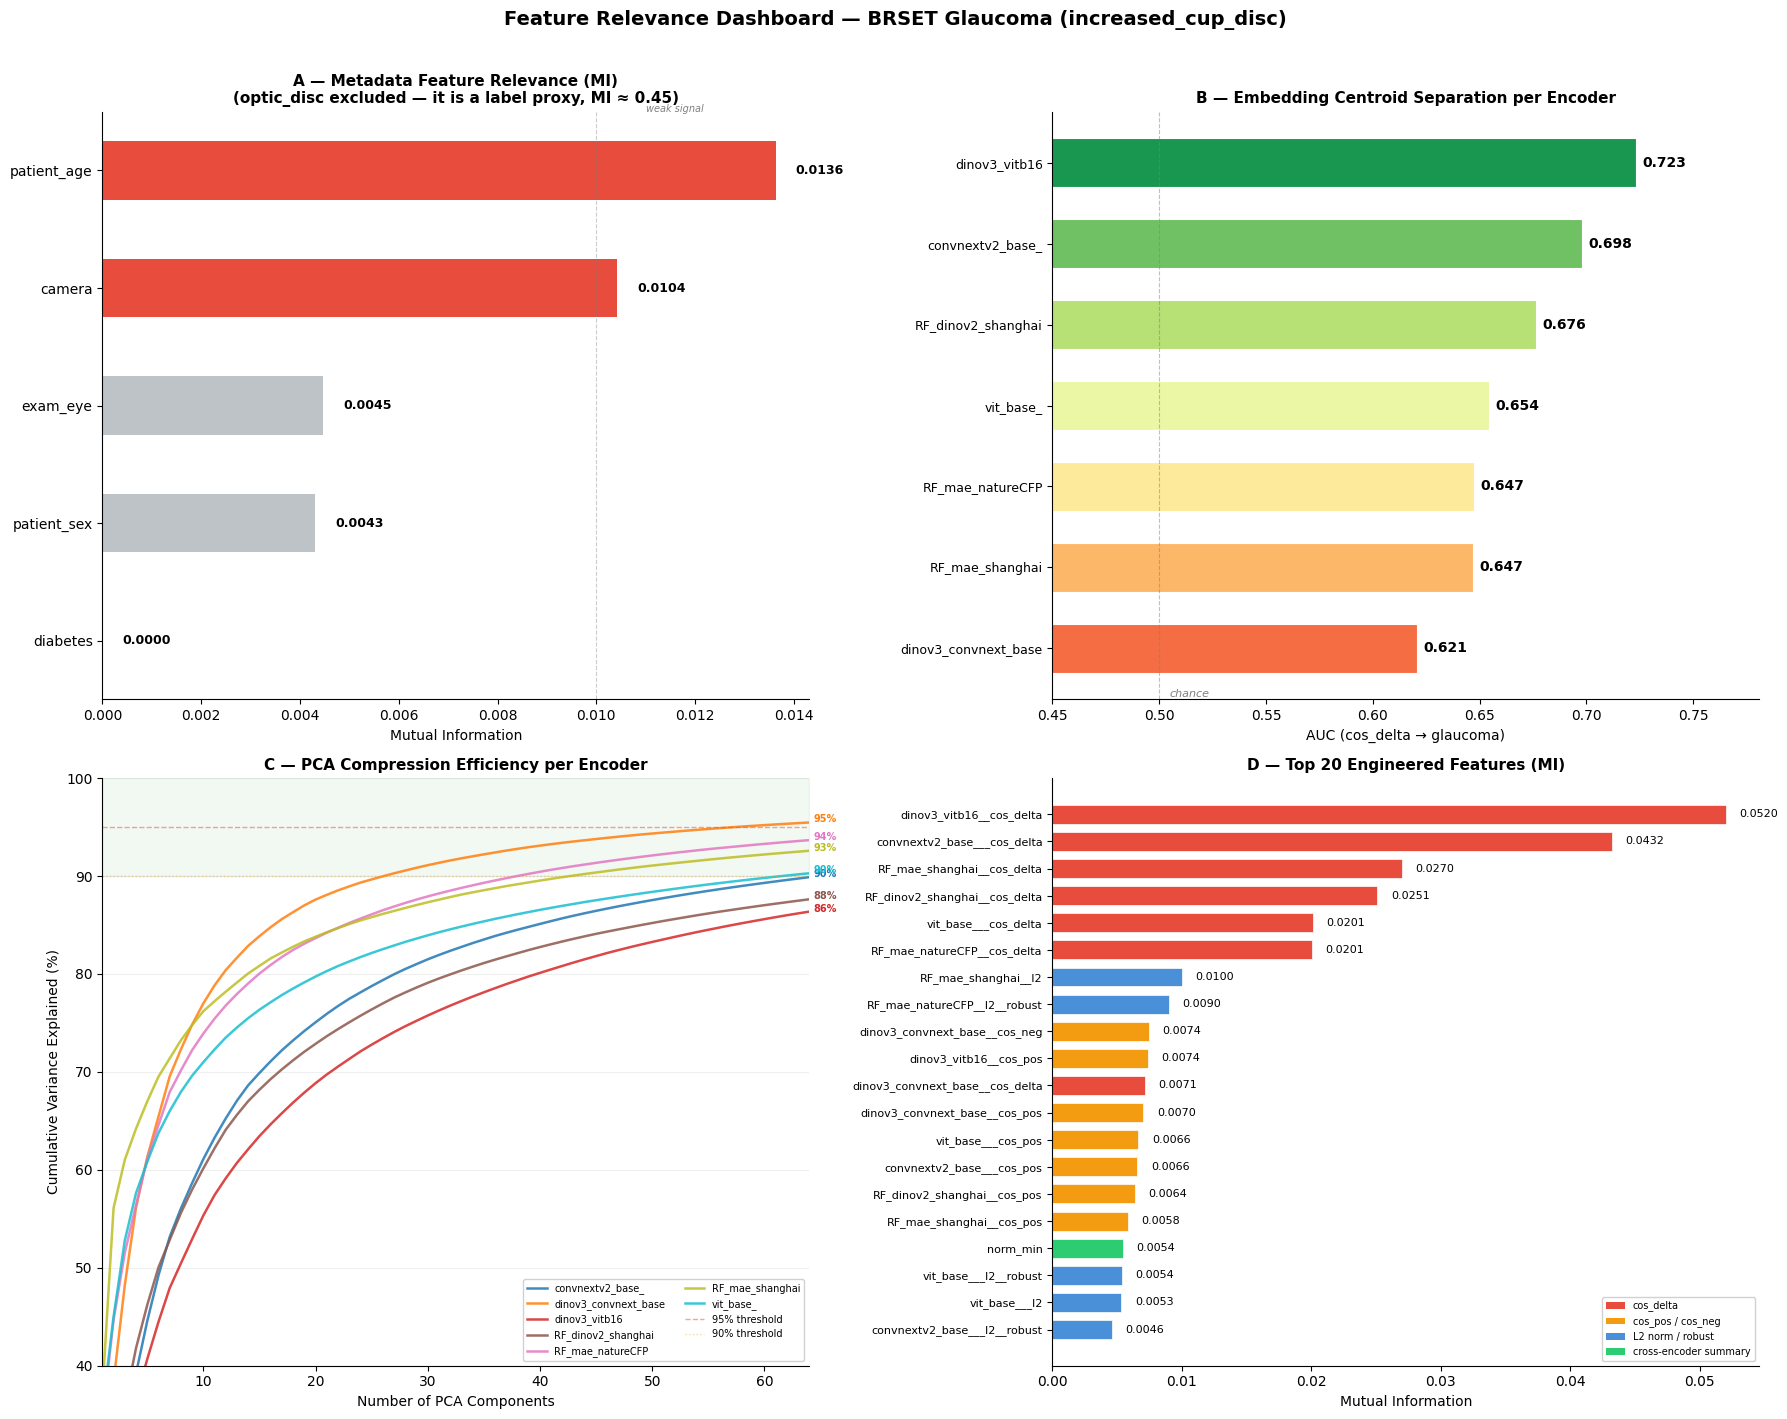

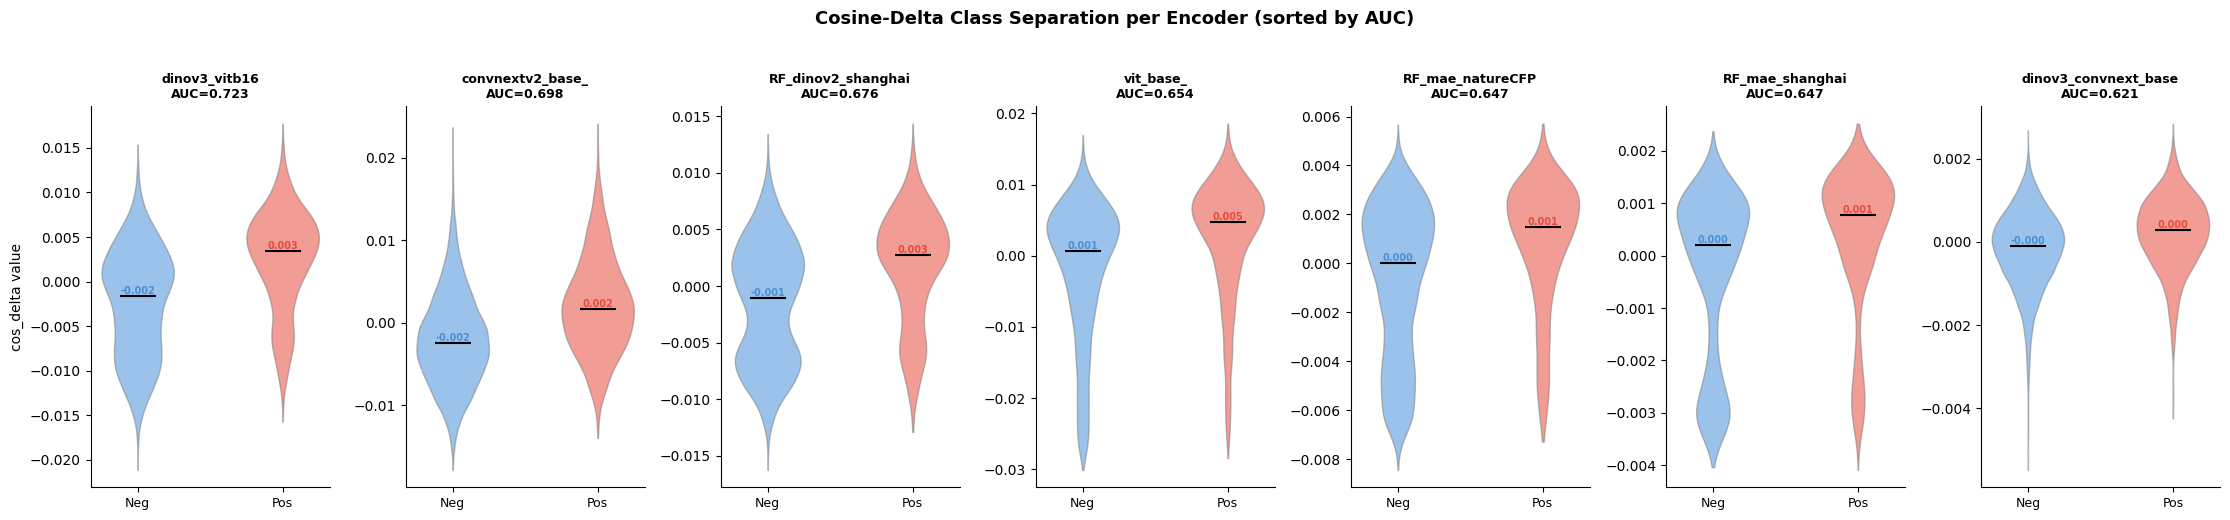


  FEATURE RELEVANCE SUMMARY
Feature                                   MI            Type
-----------------------------------------------------------------
dinov3_vitb16__cos_delta              0.0520       cos_delta
convnextv2_base___cos_delta           0.0432       cos_delta
RETFound_mae_shanghai__cos_delta      0.0270       cos_delta
RETFound_dinov2_shanghai__cos_delta   0.0251       cos_delta
vit_base___cos_delta                  0.0201       cos_delta
RETFound_mae_natureCFP__cos_delta     0.0201       cos_delta
RETFound_mae_shanghai__l2             0.0100            norm
RETFound_mae_natureCFP__l2__robust    0.0090            norm
dinov3_convnext_base__cos_neg         0.0074         cos_sim
dinov3_vitb16__cos_pos                0.0074         cos_sim
dinov3_convnext_base__cos_delta       0.0071       cos_delta
dinov3_convnext_base__cos_pos         0.0070         cos_sim
vit_base___cos_pos                    0.0066         cos_sim
convnextv2_base___cos_pos             0.0066       

In [23]:
# ═══════════════════════════════════════════════════════════════════════
# Feature Relevance — Which features carry signal for glaucoma?
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score

y_all = eda[TASK].astype(int).to_numpy()

# ─── 1. Metadata MI ────────────────────────────────────────────────
meta_names = ['optic_disc','vessels','macula','camera','exam_eye',
              'patient_age','patient_sex','diabetes']
meta_names = [c for c in meta_names if c in eda.columns]

meta_mi = {}
for col in meta_names:
    x = eda[col].copy()
    if col in ['optic_disc','vessels','macula']:
        x = pd.to_numeric(x, errors='coerce').fillna(0).to_numpy(dtype=np.float32)
    elif col == 'patient_age':
        x = pd.to_numeric(x, errors='coerce').fillna(
            np.nanmedian(pd.to_numeric(eda[col], errors='coerce'))).to_numpy(dtype=np.float32)
    else:
        codes, _ = pd.factorize(x.astype(str))
        x = codes.astype(np.float32)
    meta_mi[col] = float(mutual_info_classif(x.reshape(-1,1), y_all, random_state=0)[0])

meta_mi_s = pd.Series(meta_mi).sort_values(ascending=True)

# ─── 2. Centroid AUC values ────────────────────────────────────────
cos_delta_cols = [c for c in feat_df.columns if c.endswith('__cos_delta')]
enc_labels = [c.replace('__cos_delta','') for c in cos_delta_cols]

cos_aucs = {}
for col, label in zip(cos_delta_cols, enc_labels):
    vals = feat_df[col].to_numpy(dtype=np.float32)
    mask = ~np.isnan(vals)
    try:
        cos_aucs[label] = roc_auc_score(y_all[mask], vals[mask])
    except ValueError:
        cos_aucs[label] = 0.5
cos_auc_s = pd.Series(cos_aucs).sort_values(ascending=True)

# ─── 3. Engineered feature MI ──────────────────────────────────────
eng_cols = [c for c in feat_df.columns if any(
    c.endswith(s) for s in ['__l2','__l2_sq','__robust','__cos_pos','__cos_neg','__cos_delta']
)] + [c for c in ['norm_mean','norm_std','norm_min','norm_max'] if c in feat_df.columns]
eng_cols = sorted(set(eng_cols))

rng_sub = np.random.default_rng(42)
sub_idx = rng_sub.choice(len(feat_df), size=min(5000, len(feat_df)), replace=False)
X_sub = feat_df.iloc[sub_idx][eng_cols].to_numpy(dtype=np.float32)
y_sub = feat_df.iloc[sub_idx][TASK].astype(int).to_numpy()
X_sub = np.nan_to_num(X_sub, nan=0.0)
mi_eng = mutual_info_classif(X_sub, y_sub, random_state=0)
mi_eng_s = pd.Series(mi_eng, index=eng_cols).sort_values(ascending=False)

# ═══════════════════════════════════════════════════════════════════════
# FIGURE 1 — 4-Panel Feature Relevance Dashboard
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# ─── Panel A: Metadata MI (excluding optic_disc for readability) ────
ax = axes[0, 0]
# separate optic_disc (leakage) from the rest
meta_no_leak = meta_mi_s.drop('optic_disc', errors='ignore')
bar_colors_meta = []
for name, v in meta_no_leak.items():
    if v > 0.01:
        bar_colors_meta.append('#e74c3c')
    elif v > 0.005:
        bar_colors_meta.append('#f39c12')
    else:
        bar_colors_meta.append('#bdc3c7')
meta_no_leak.plot.barh(ax=ax, color=bar_colors_meta)
for j, (name, v) in enumerate(meta_no_leak.items()):
    ax.text(v + meta_no_leak.max()*0.03, j, f'{v:.4f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Mutual Information', fontsize=10)
ax.set_title('A — Metadata Feature Relevance (MI)\n(optic_disc excluded — it is a label proxy, MI ≈ 0.45)',
             fontsize=11, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.axvline(0.01, ls='--', color='gray', alpha=0.4, linewidth=0.8)
ax.text(0.011, len(meta_no_leak)-0.5, 'weak signal', fontsize=7, color='gray', style='italic')

# ─── Panel B: Centroid AUC per encoder ──────────────────────────────
ax = axes[0, 1]
short_enc = [n.replace('RETFound_','RF_') for n in cos_auc_s.index]
cmap_auc = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(cos_auc_s)))
bars_auc = ax.barh(range(len(cos_auc_s)), cos_auc_s.values, color=cmap_auc,
                   edgecolor='white', linewidth=0.8, height=0.6)
ax.set_yticks(range(len(cos_auc_s)))
ax.set_yticklabels(short_enc, fontsize=9)
for j, v in enumerate(cos_auc_s.values):
    ax.text(v + 0.003, j, f'{v:.3f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('AUC (cos_delta → glaucoma)', fontsize=10)
ax.set_title('B — Embedding Centroid Separation per Encoder', fontsize=11, fontweight='bold')
ax.axvline(0.5, ls='--', color='gray', alpha=0.5, linewidth=0.8)
ax.text(0.505, -0.6, 'chance', fontsize=8, color='gray', style='italic')
ax.spines[['top','right']].set_visible(False)
ax.set_xlim(0.45, cos_auc_s.max() * 1.08)

# ─── Panel C: PCA variance curves ──────────────────────────────────
ax = axes[1, 0]
pca_colors = plt.cm.tab10(np.linspace(0, 1, len(pca_models)))
for (enc, model), color in zip(pca_models.items(), pca_colors):
    cumvar = np.cumsum(model.explained_variance_ratio_) * 100
    short = enc.replace('RETFound_','RF_')
    ax.plot(range(1, len(cumvar)+1), cumvar, label=short,
            linewidth=1.8, color=color, alpha=0.85)
    # annotate final variance
    ax.annotate(f'{cumvar[-1]:.0f}%', xy=(len(cumvar), cumvar[-1]),
                fontsize=7, color=color, fontweight='bold',
                xytext=(3, 0), textcoords='offset points')
ax.axhline(95, ls='--', color='#e74c3c', alpha=0.5, linewidth=1, label='95% threshold')
ax.axhline(90, ls=':', color='#f39c12', alpha=0.4, linewidth=1, label='90% threshold')
ax.fill_between([1, PCA_N_COMPONENTS], 90, 100, alpha=0.05, color='green')
ax.set_xlabel('Number of PCA Components', fontsize=10)
ax.set_ylabel('Cumulative Variance Explained (%)', fontsize=10)
ax.set_title('C — PCA Compression Efficiency per Encoder', fontsize=11, fontweight='bold')
ax.legend(fontsize=7, loc='lower right', ncol=2, framealpha=0.9)
ax.set_xlim(1, PCA_N_COMPONENTS)
ax.set_ylim(40, 100)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.2)

# ─── Panel D: Top engineered features by MI ─────────────────────────
ax = axes[1, 1]
top_n = 20
mi_top = mi_eng_s.head(top_n).sort_values(ascending=True)

# colour by feature type
bar_colors_eng = []
for idx in mi_top.index:
    if 'cos_delta' in idx:
        bar_colors_eng.append('#e74c3c')
    elif 'cos_pos' in idx or 'cos_neg' in idx:
        bar_colors_eng.append('#f39c12')
    elif 'l2' in idx or 'robust' in idx:
        bar_colors_eng.append('#4a90d9')
    elif 'norm_' in idx:
        bar_colors_eng.append('#2ecc71')
    else:
        bar_colors_eng.append('#95a5a6')

short_feat = [f.replace('RETFound_','RF_') for f in mi_top.index]
bars_eng = ax.barh(range(len(mi_top)), mi_top.values, color=bar_colors_eng,
                   edgecolor='white', linewidth=0.5, height=0.7)
ax.set_yticks(range(len(mi_top)))
ax.set_yticklabels(short_feat, fontsize=8)
for j, v in enumerate(mi_top.values):
    ax.text(v + mi_top.max()*0.02, j, f'{v:.4f}', va='center', fontsize=8)
ax.set_xlabel('Mutual Information', fontsize=10)
ax.set_title(f'D — Top {top_n} Engineered Features (MI)', fontsize=11, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
# legend for feature types
from matplotlib.patches import Patch
legend_items = [Patch(facecolor='#e74c3c', label='cos_delta'),
                Patch(facecolor='#f39c12', label='cos_pos / cos_neg'),
                Patch(facecolor='#4a90d9', label='L2 norm / robust'),
                Patch(facecolor='#2ecc71', label='cross-encoder summary')]
ax.legend(handles=legend_items, fontsize=7, loc='lower right', framealpha=0.9)

fig.suptitle('Feature Relevance Dashboard — BRSET Glaucoma (increased_cup_disc)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'feature_relevance_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# FIGURE 2 — Class-Conditional Violin Plots for Cosine-Delta
# ═══════════════════════════════════════════════════════════════════════
n_enc = min(len(cos_delta_cols), 7)
fig2, axes2 = plt.subplots(1, n_enc, figsize=(3.2 * n_enc, 5), sharey=False)
if not hasattr(axes2, '__len__'):
    axes2 = [axes2]

# sort encoders by AUC (best first)
sorted_enc = cos_auc_s.sort_values(ascending=False)
sorted_cols = [f'{enc}__cos_delta' for enc in sorted_enc.index]
sorted_labels = [enc.replace('RETFound_','RF_') for enc in sorted_enc.index]

for i, (col, label) in enumerate(zip(sorted_cols[:n_enc], sorted_labels[:n_enc])):
    ax2 = axes2[i]
    neg_vals = feat_df.loc[eda[TASK]==0, col].dropna().values
    pos_vals = feat_df.loc[eda[TASK]==1, col].dropna().values

    parts = ax2.violinplot([neg_vals, pos_vals], positions=[0, 1],
                           showmedians=True, showextrema=False)
    for pc, clr in zip(parts['bodies'], [C_NEG, C_POS]):
        pc.set_facecolor(clr)
        pc.set_alpha(0.55)
        pc.set_edgecolor('gray')
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.5)

    # add individual medians as text
    med_neg = float(np.median(neg_vals))
    med_pos = float(np.median(pos_vals))
    ax2.text(0, med_neg, f'{med_neg:.3f}', ha='center', va='bottom', fontsize=7, color=C_NEG, fontweight='bold')
    ax2.text(1, med_pos, f'{med_pos:.3f}', ha='center', va='bottom', fontsize=7, color=C_POS, fontweight='bold')

    auc_val = cos_aucs.get(sorted_enc.index[i], 0.5)
    ax2.set_xticks([0, 1])
    ax2.set_xticklabels(['Neg', 'Pos'], fontsize=9)
    ax2.set_title(f'{label}\nAUC={auc_val:.3f}', fontsize=9, fontweight='bold')
    ax2.spines[['top','right']].set_visible(False)
    if i == 0:
        ax2.set_ylabel('cos_delta value', fontsize=10)

fig2.suptitle('Cosine-Delta Class Separation per Encoder (sorted by AUC)',
              fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'cosine_delta_violins.png'), dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# Summary table
# ═══════════════════════════════════════════════════════════════════════
print('\n' + '='*65)
print('  FEATURE RELEVANCE SUMMARY')
print('='*65)
print(f'{"Feature":<35} {"MI":>8} {"Type":>15}')
print('-' * 65)
for feat, mi_val in mi_eng_s.head(15).items():
    ftype = ('cos_delta' if 'cos_delta' in feat else
             'cos_sim'   if 'cos_' in feat else
             'norm'      if 'l2' in feat or 'robust' in feat else
             'summary')
    print(f'{feat:<35} {mi_val:>8.4f} {ftype:>15}')
print('-' * 65)
print(f'Metadata leakage leader:  optic_disc    MI = {meta_mi.get("optic_disc", 0):.4f}')
print(f'Best centroid encoder:    {cos_auc_s.idxmax():<20s} AUC = {cos_auc_s.max():.4f}')
print(f'Best engineered feature:  {mi_eng_s.idxmax():<20s} MI  = {mi_eng_s.max():.4f}')
print('='*65)

### 3.5 — Feature Relevance Dashboard
Four-panel visualization summarising which features carry signal for glaucoma detection:

| Panel | What it shows |
|:------|:--------------|
| **A** | Metadata MI (excluding optic_disc label proxy) — patient_age leads but all metadata has weak signal |
| **B** | Centroid cosine-delta AUC per encoder — dinov3_vitb16 achieves the best single-feature separation |
| **C** | PCA compression curves — all encoders reach 86–96% variance in 64 components |
| **D** | Top 20 engineered features ranked by MI — cos_delta features dominate the leaderboard |

Followed by class-conditional violin plots showing the cosine-delta distribution split by glaucoma status.

---
## Part 4 — Splits & Export

**Goal:** Persist patient-stratified train/val/test splits and export all engineered features for downstream R-run pipelines.

Outputs saved to `artifacts/brset_eda_fe/`:
| File | Content |
|:-----|:--------|
| `splits_patient.csv` | Patient-level split assignments (train / val / test) |
| `splits_image.csv` | Image-level split assignments with target labels |
| `features_engineered_image_level.csv` | 487 engineered features (norms, PCA, centroids) |
| `features_raw_embeddings_image_level.csv` | Full raw embedding vectors (~6.6k dims) |
| `feature_dictionary.json` | Schema of all feature groups for programmatic access |

In [16]:
# Section 12 — Train/Val/Test Split by Patient + Persist Splits

# Persist splits: patient_id -> split and image_id -> split

splits_pat = (feat_df[['patient_id','split']]
              .drop_duplicates(subset=['patient_id'])
              .sort_values('patient_id'))

splits_img = (feat_df[['image_id','image_key','patient_id','split',TASK]]
              .drop_duplicates(subset=['image_key'])
              .sort_values('image_key'))

splits_pat.to_csv(OUTPUT_DIR / 'splits_patient.csv', index=False)
splits_img.to_csv(OUTPUT_DIR / 'splits_image.csv', index=False)

print('Saved:', OUTPUT_DIR / 'splits_patient.csv')
print('Saved:', OUTPUT_DIR / 'splits_image.csv')

# Split diagnostics
for s in ['train','val','test']:
    pids = splits_pat[splits_pat['split']==s]['patient_id']
    img = splits_img[splits_img['split']==s]
    pos_pat = float(feat_df[feat_df['patient_id'].isin(pids)].groupby('patient_id')[TASK].max().mean())
    pos_img = float(img[TASK].mean())
    print(f'{s:>5}: patients={len(pids):,} | images={len(img):,} | pos_pat={pos_pat:.3%} | pos_img={pos_img:.3%}')


Saved: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\artifacts\brset_eda_fe\splits_patient.csv
Saved: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\artifacts\brset_eda_fe\splits_image.csv
train: patients=5,796 | images=11,047 | pos_pat=23.741% | pos_img=19.616%
  val: patients=1,023 | images=1,950 | pos_pat=23.754% | pos_img=20.513%
 test: patients=1,705 | images=3,269 | pos_pat=23.754% | pos_img=19.425%


In [17]:
# Section 13 — Export Final Feature Matrices (X, y) + Feature Dictionary

# Build feature lists
norm_feats = [c for c in feat_df.columns if c.endswith('__l2') or c.endswith('__l2_sq') or c.endswith('__robust')]
summary_feats = ['norm_mean','norm_std','norm_min','norm_max']

engineered_feats = []
engineered_feats.extend(norm_feats)
engineered_feats.extend([c for c in summary_feats if c in feat_df.columns])
engineered_feats.extend([c for c in pca_features if c in feat_df.columns])
engineered_feats.extend([c for c in centroid_features if c in feat_df.columns])

engineered_feats = sorted(set(engineered_feats))
print('Engineered feature count:', len(engineered_feats))

# Targets
y_img = feat_df[TASK].astype(int).to_numpy()

# Export table (image-level)
export_cols = ['image_id','image_key','patient_id','split',TASK] + engineered_feats
export_df = feat_df[export_cols].copy()

out_csv = OUTPUT_DIR / 'features_engineered_image_level.csv'
export_df.to_csv(out_csv, index=False)
print('Saved:', out_csv)

# Optionally export raw wide embeddings (very large)
if KEEP_RAW_EMBEDDINGS:
    raw_cols = []
    for cols in encoder_feature_groups.values():
        raw_cols.extend(cols)
    raw_cols = ['image_id','image_key','patient_id','split',TASK] + raw_cols

    raw_out = OUTPUT_DIR / 'features_raw_embeddings_image_level.csv'
    print('\nWriting raw embeddings CSV (this can be large):', raw_out)
    merged2 = merged.merge(feat_df[['image_key','split']], on='image_key', how='left')
    merged2[raw_cols].to_csv(raw_out, index=False)
    print('Saved:', raw_out)

# Feature dictionary
feat_dict = {
    'task': TASK,
    'keep_raw_embeddings': bool(KEEP_RAW_EMBEDDINGS),
    'engineered_features': {
        'norm_per_encoder': encoder_norm_cols,
        'summary_norms': summary_feats,
        'pca_features': pca_features,
        'centroid_features': centroid_features,
    },
    'encoder_feature_groups': encoder_feature_groups,
}

(OUTPUT_DIR / 'feature_dictionary.json').write_text(json.dumps(feat_dict, indent=2), encoding='utf-8')
print('Saved:', OUTPUT_DIR / 'feature_dictionary.json')


Engineered feature count: 487
Saved: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\artifacts\brset_eda_fe\features_engineered_image_level.csv

Writing raw embeddings CSV (this can be large): c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\artifacts\brset_eda_fe\features_raw_embeddings_image_level.csv
Saved: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\artifacts\brset_eda_fe\features_raw_embeddings_image_level.csv
Saved: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\artifacts\brset_eda_fe\feature_dictionary.json


In [18]:
# Section 14 — Repo Cleanup Helpers (archive/remove obsolete docs/artifacts safely)
# This is SAFE by default: it only lists candidates.
# To actually archive, set DO_ARCHIVE=True and CONFIRM='YES'.

import shutil
from datetime import datetime

DO_ARCHIVE = False
CONFIRM = ''  # must be 'YES' to proceed

candidates = [
    PROJECT_ROOT / 'docs' / 'PROJECT_BRIEF.md',
    PROJECT_ROOT / 'docs' / 'EXPERIMENT_JOURNAL.md',
]

# You can add more candidates here if needed.

existing = [p for p in candidates if p.exists()]
print('Cleanup candidates (existing):')
for p in existing:
    print(' -', p)

archive_root = PROJECT_ROOT / 'docs' / '_archive'
archive_root.mkdir(parents=True, exist_ok=True)

if DO_ARCHIVE and CONFIRM == 'YES':
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    dest_dir = archive_root / ts
    dest_dir.mkdir(parents=True, exist_ok=True)

    moved = []
    for p in existing:
        dest = dest_dir / p.name
        shutil.move(str(p), str(dest))
        moved.append({'from': str(p), 'to': str(dest)})

    log_path = OUTPUT_DIR / 'cleanup_log.json'
    log_path.write_text(json.dumps({'timestamp': ts, 'moved': moved}, indent=2), encoding='utf-8')
    print('\nArchived files to:', dest_dir)
    print('Wrote cleanup log:', log_path)
else:
    print('\nNo files were moved. Set DO_ARCHIVE=True and CONFIRM="YES" to archive.')


Cleanup candidates (existing):
 - c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\docs\EXPERIMENT_JOURNAL.md

No files were moved. Set DO_ARCHIVE=True and CONFIRM="YES" to archive.


---
## Downstream Integration Guide

### Using these artifacts in R-run pipelines

| Artifact | How to use |
|:---------|:-----------|
| `splits_patient.csv` | Load and merge on `patient_id` to keep **patient-wise** train/val/test splits consistent across experiments |
| `features_engineered_image_level.csv` | Merge on `image_id` or `image_key` into your modeling DataFrame to add the 487 engineered features |
| `feature_dictionary.json` | Programmatically look up which columns belong to each feature group (norms, PCA, centroids) |
| `pca_models/*.json`, `centroids/*.npz` | Re-apply transformations on new data without refitting |

### Handling optic_disc (label-proxy leakage)
For glaucoma (`increased_cup_disc`), the `optic_disc` column has MI ≈ 0.45 — it is a **direct label proxy**.
- **Do not** include it as a standard metadata feature
- Use the **partial-availability masking** strategy from R27: train/val/test masking + missingness indicator column

### Example integration (R27 MLP pipeline)
```python
# After loading df = ds.df.copy()
eng = pd.read_csv('artifacts/brset_eda_fe/features_engineered_image_level.csv')
df = df.merge(eng[['image_id'] + selected_features], on='image_id', how='left')
# Extend METADATA_COLS to include engineered columns as 'numeric'
```